<a href="https://colab.research.google.com/github/AkankshaB123/python/blob/main/Price_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import statsmodels.api as sm

# -----------------------------
# 1. Load data
# -----------------------------
# Replace with your actual file
df = pd.read_csv("/content/sample_data/Case_Study_Urgency_Message_Data.xlsx - Aggregated.csv")

/tmp/ipykernel_5314/1349077752.py:8: DtypeWarning: Columns (19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/sample_data/Case_Study_Urgency_Message_Data.xlsx - Aggregated.csv")


In [ ]:
df.head(2)

,#,ADR_USD,hotel_id,city_id,City,star_rating,accommadation_type_name,chain_hotel,booking_date,checkin_date,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47
0,1,71.06,"297,388","9,395",City_A,2.5,Hotel,non-chain,8/2/2016,10/1/2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,76.56,"298,322","9,395",City_A,3.0,Hotel,non-chain,8/2/2016,10/1/2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['#', 'ADR_USD', 'hotel_id', 'city_id', 'City', 'star_rating',
       'accommadation_type_name', 'chain_hotel', 'booking_date',
       'checkin_date', 'checkout_date', 'Stay_duration', 'Week_num',
       'Month_no', 'Date_Diff', 'Date_Range', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18', 'Assumption: Every line item is a unique booking',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31',
       'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35',
       'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39',
       'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43',
       'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47'],
      dtype='object')

In [ ]:
# -----------------------------
# 2. Select only needed columns
# -----------------------------
df = df[['ADR_USD', 'star_rating', 'Date_Diff','city_id']]

# Drop missing values if any
df = df.dropna()

In [ ]:
df.head(2)

,ADR_USD,star_rating,Date_Diff,city_id
0,71.06,2.5,60,"9,395"
1,76.56,3.0,60,"9,395"


In [ ]:
import pandas as pd
import statsmodels.api as sm

# -----------------------------
# 3. Define variables
# -----------------------------
# Convert 'ADR_USD' to numeric, coercing errors to NaN
# First, convert to string, remove commas and strip spaces, then convert to numeric
df['ADR_USD'] = df['ADR_USD'].astype(str).str.replace(',', '', regex=False).str.strip()
df['ADR_USD'] = pd.to_numeric(df['ADR_USD'], errors='coerce')

# Drop any rows where 'ADR_USD' became NaN after conversion
df = df.dropna(subset=['ADR_USD'])

# Convert 'city_id' to numeric by removing commas
df['city_id'] = df['city_id'].astype(str).str.replace(',', '', regex=False).str.strip()
df['city_id'] = pd.to_numeric(df['city_id'], errors='coerce')

# Drop any rows where 'city_id' became NaN after conversion
df = df.dropna(subset=['city_id'])

X = df[['star_rating', 'Date_Diff']]   # independent variables
y = df['ADR_USD']                   # dependent variable

# Add constant (intercept)
X = sm.add_constant(X)

# -----------------------------
# 4. Fit regression model
# -----------------------------
model = sm.OLS(y, X).fit()

# -----------------------------
# 5. Show statistics
# -----------------------------
print("\n=== Model Summary ===")
print(model.summary())

# -----------------------------
# 6. Extract coefficients
# -----------------------------
print("\n=== Coefficients ===")
coefficients = model.params
print(coefficients)

# -----------------------------
# 7. Interpretation (multipliers)
# -----------------------------
print("\n=== Multipliers Interpretation ===")
for var in coefficients.index:
    print(f"{var}: {coefficients[var]:.4f}")


=== Model Summary ===
                            OLS Regression Results                            
Dep. Variable:                ADR_USD   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     4145.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        16:24:01   Log-Likelihood:            -3.0658e+05
No. Observations:               49064   AIC:                         6.132e+05
Df Residuals:                   49061   BIC:                         6.132e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -32.0908     

In [ ]:
def predict_adr(star_rating_input, date_diff_input, coefficients):
    # The prediction is const + (star_rating_coef * star_rating) + (date_diff_coef * date_diff)
    predicted_value = coefficients['const'] + \
                      (coefficients['star_rating'] * star_rating_input) + \
                      (coefficients['Date_Diff'] * date_diff_input)
    return predicted_value

print("Simulator function 'predict_adr' defined.")

Simulator function 'predict_adr' defined.


Now, let's use the simulator to predict `ADR_USD` for different scenarios. We'll create a DataFrame to easily compare various inputs and their predicted outcomes.

In [ ]:
import pandas as pd

# Define some scenarios for star_rating and Date_Diff
scenarios = [
    {'star_rating': 3.0, 'Date_Diff': 30},
    {'star_rating': 4.0, 'Date_Diff': 30},
    {'star_rating': 3.0, 'Date_Diff': 60},
    {'star_rating': 5.0, 'Date_Diff': 10},
    {'star_rating': 2.5, 'Date_Diff': 90} # Example from original data
]

# Create a DataFrame from scenarios
simulation_df = pd.DataFrame(scenarios)

# Apply the prediction function to each row
simulation_df['predicted_ADR_USD'] = simulation_df.apply(lambda row: predict_adr(
    row['star_rating'], row['Date_Diff'], coefficients), axis=1)

print("Predicted ADR_USD for various scenarios:")
display(simulation_df)

Predicted ADR_USD for various scenarios:


,star_rating,Date_Diff,predicted_ADR_USD
0,3.0,30,145.122987
1,4.0,30,189.177094
2,3.0,60,174.197214
3,5.0,10,213.848384
4,2.5,90,181.244387


### Data Visualization: Scatterplots

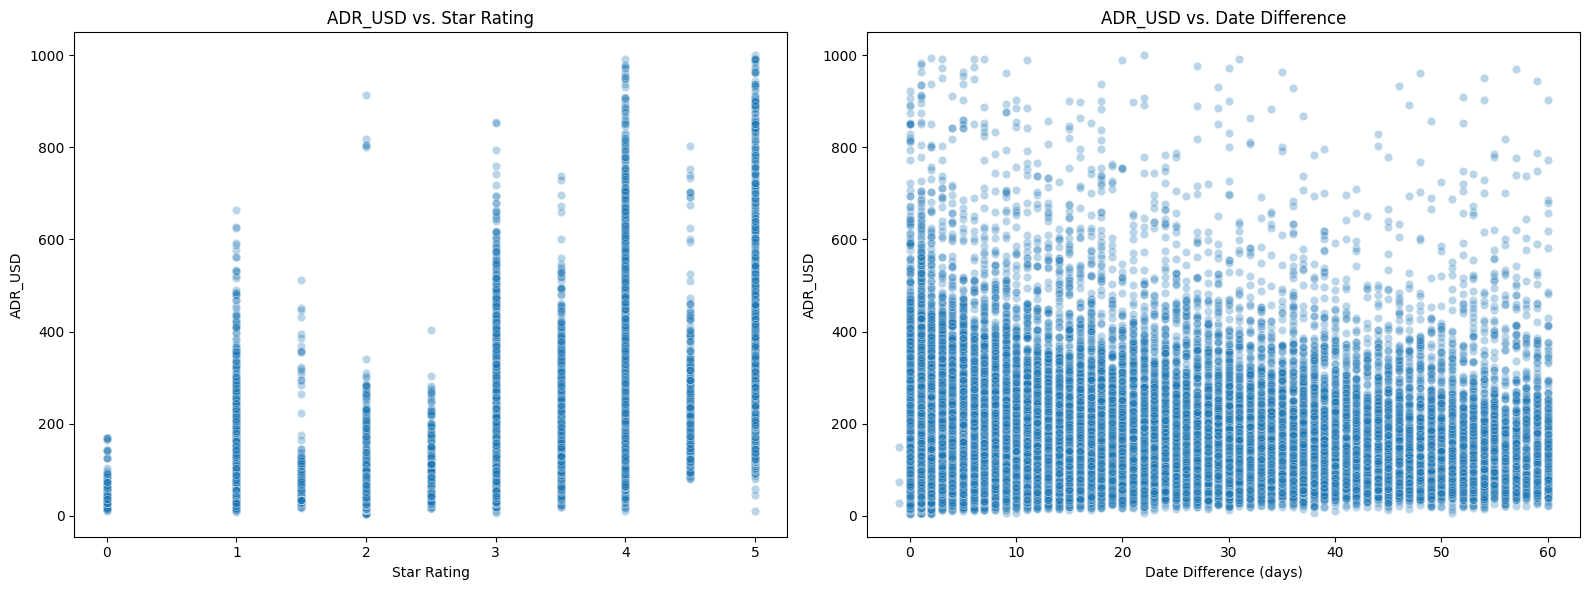

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatterplot 1: ADR_USD vs star_rating
sns.scatterplot(x='star_rating', y='ADR_USD', data=df, ax=axes[0], alpha=0.3)
axes[0].set_title('ADR_USD vs. Star Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('ADR_USD')

# Scatterplot 2: ADR_USD vs Date_Diff
sns.scatterplot(x='Date_Diff', y='ADR_USD', data=df, ax=axes[1], alpha=0.3)
axes[1].set_title('ADR_USD vs. Date Difference')
axes[1].set_xlabel('Date Difference (days)')
axes[1].set_ylabel('ADR_USD')

plt.tight_layout()
plt.show()

### Correlation Heatmap

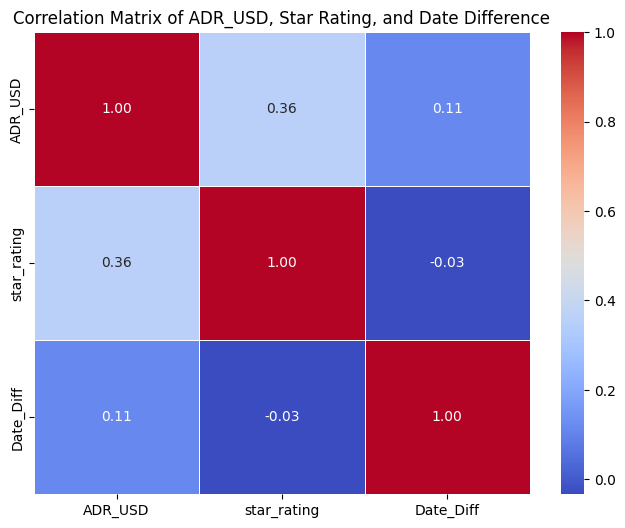

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numerical columns for correlation analysis
# Exclude 'city_id' as its correlation might not be meaningful in a linear sense due to its nature
correlation_df = df[['ADR_USD', 'star_rating', 'Date_Diff']]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of ADR_USD, Star Rating, and Date Difference')
plt.show()

---

### Interactive Simulator

In [ ]:
# Allow user to input values
star_rating_input = float(input("Enter the star rating (e.g., 3.5, 4.0): "))
date_diff_input = int(input("Enter the date difference in days (e.g., 30, 60): "))

# Predict ADR_USD using the simulator function
predicted_adr = predict_adr(star_rating_input, date_diff_input, coefficients)

print(f"\nFor a hotel with {star_rating_input} stars and booked {date_diff_input} days in advance, the predicted ADR_USD is: {predicted_adr:.2f}")

Enter the star rating (e.g., 3.5, 4.0): 3
Enter the date difference in days (e.g., 30, 60): 60

For a hotel with 3.0 stars and booked 60 days in advance, the predicted ADR_USD is: 174.20
